# Current datasets:

| Path | Description | Batch | Platform |
| :----: | :---: | :-------: | :-------: |
| /gpfs/gibbs/pi/zhao/xc384/data/RongData/rna_5tmp.h5ad      | Mouse Brain     | timepoint     | spatial ARP-seq |
| /gpfs/gibbs/pi/zhao/xc384/data/RongData/atac_5tmp.h5ad      | Mouse Brain     | timepoint     | spatial ARP-seq |
| Accessible from Bioconductor package spatialLIBD       | Human DLPFC   |          | 10x Visium |
| https://www.10xgenomics.com/datasets?configure%5BhitsPerPage%5D=50&configure%5BmaxValuesPerFacet%5D=1000&page=2 | Human breast cancer, lymph node, brain ... |          | 10x Visium |
| https://openproblems.bio/datasets/zenodo_spatial/slideseqv2/mouse_cerebellum | Mouse Cerebellum |          | Slide-seq v2 |
| https://alleninstitute.github.io/abc_atlas_access/descriptions/Zhuang_dataset.html | Whole Mouse Brain|          | MERFISH |
| https://linnarssonlab.org/osmFISH/availability/ | Mouse somatosensory cortex |          | osmFISH |
| https://github.com/CaiGroup/seqFISH-PLUS | Mouse Brain |          | SeqFISH+ |
| somewhere in zhao folder | Mouse |          | Stereo-seq |
| https://openproblems.bio/datasets | Human & Mouse |          | 10x Visium, MERFISH, DBiT |


In [ ]:
# referencing code uses: https://squidpy.readthedocs.io/en/latest/notebooks/tutorials/tutorial_merfish.html

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

try:
    import anndata as ad
except ImportError as e:
    raise SystemExit("Please install anndata (and typically scanpy) to run this evaluator.") from e

In [2]:
def _find_coords(adata) -> Tuple[str, Optional[Tuple[str, str]]]:
    """
    Returns:
      - source: "obs" | "obsm" | "missing"
      - obs_cols: (x_col, y_col) if source == "obs" else None
    """
    obs = adata.obs

    # Common obs coordinate column pairs
    for x_col, y_col in [
        ("x", "y"),
        ("X", "Y"),
        ("spatial_x", "spatial_y"),
        ("x_coord", "y_coord"),
        ("pxl_col_in_fullres", "pxl_row_in_fullres"),  # Visium-like
        ("array_col", "array_row"),  # Visium grid indices (still useful)
    ]:
        if x_col in obs.columns and y_col in obs.columns:
            return "obs", (x_col, y_col)

    # Common Scanpy convention
    if "spatial" in adata.obsm:
        arr = adata.obsm["spatial"]
        if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[0] == adata.n_obs and arr.shape[1] >= 2:
            return "obsm", None

    return "missing", None


def _add_coord_checks(adata, checks: Dict[str, Any], errors: List[str]) -> None:
    source, obs_cols = _find_coords(adata)
    checks["coords_source"] = source

    if source == "missing":
        errors.append("Missing spatial coordinates (need obs x/y columns or obsm['spatial']).")
        return

    if source == "obsm":
        xy = np.asarray(adata.obsm["spatial"][:, :2], dtype=float)
        n_bad = int(np.sum(~np.isfinite(xy)))
        checks["coords_n_nonfinite"] = n_bad
        if n_bad > 0:
            errors.append(f"Spatial coordinates in obsm['spatial'] contain non-finite values (n={n_bad}).")
        return

    # source == "obs"
    x_col, y_col = obs_cols  # type: ignore[misc]
    checks["coords_x_col"] = x_col
    checks["coords_y_col"] = y_col

    x = pd.to_numeric(adata.obs[x_col], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(adata.obs[y_col], errors="coerce").to_numpy(dtype=float)

    n_bad = int(np.sum(~np.isfinite(x)) + np.sum(~np.isfinite(y)))
    checks["coords_n_nonfinite"] = n_bad
    if n_bad > 0:
        errors.append(
            f"Spatial coordinate columns ({x_col},{y_col}) contain NaN/inf after numeric coercion (n={n_bad})."
        )










def _read_h5ad(path: str) -> "ad.AnnData":
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    return ad.read_h5ad(path)


def _has_all(container: Any, keys: List[str]) -> Tuple[bool, List[str]]:
    missing = [k for k in keys if k not in container]
    return (len(missing) == 0, missing)


def _is_finite_array(x: np.ndarray) -> bool:
    if x is None:
        return False
    x = np.asarray(x)
    if x.size == 0:
        return False
    return np.isfinite(x).all()


def _safe_series_values(adata: "ad.AnnData", obs_key: str) -> np.ndarray:
    if obs_key not in adata.obs:
        raise KeyError(f"obs[{obs_key}] not found")
    vals = adata.obs[obs_key].to_numpy()
    # normalize pandas categorical/object to str for stable comparisons
    return vals.astype(str)


def _align_on_obs_names(pred: "ad.AnnData", gold: "ad.AnnData") -> Tuple["ad.AnnData", "ad.AnnData"]:
    """
    Align pred and gold to shared obs_names (intersection), sorted identically.
    This avoids failing when agent filtered differently. Metrics then reflect overlap subset.
    """
    common = pred.obs_names.intersection(gold.obs_names)
    if len(common) == 0:
        raise ValueError("No overlapping cells (obs_names) between pred and gold AnnData.")
    common = common.sort_values()
    return pred[common].copy(), gold[common].copy()


def _rank_genes_groups_to_topk(adata: "ad.AnnData", group: str, k: int) -> List[str]:
    """
    Extract top-k genes for a group from adata.uns['rank_genes_groups'].

    Supports Scanpy's standard structure:
      adata.uns['rank_genes_groups']['names'] could be:
        - structured array with dtype.names == groups
        - 2D array (n_genes, n_groups) with separate 'groups' list

    We try to handle common variants.
    """
    if "rank_genes_groups" not in adata.uns:
        raise KeyError("uns['rank_genes_groups'] missing")

    rgg = adata.uns["rank_genes_groups"]
    names = rgg.get("names", None)
    if names is None:
        raise KeyError("uns['rank_genes_groups']['names'] missing")

    # Case 1: structured array (np.ndarray with dtype.names)
    if hasattr(names, "dtype") and getattr(names.dtype, "names", None):
        if group not in names.dtype.names:
            raise KeyError(f"Group '{group}' not found in rank_genes_groups names dtype.names")
        top = list(np.array(names[group])[:k].astype(str))
        return top

    # Case 2: plain 2D array with group ordering given by rgg['params']['groupby'] or rgg['names'].columns
    groups = rgg.get("names_group", None)  # rarely
    if groups is None:
        # Scanpy often stores group names in rgg['names'].dtype.names (structured) OR in rgg['params']['groups']
        groups = rgg.get("params", {}).get("groups", None)

    # Another common: rgg['names'] is a pandas DataFrame serialized? In h5ad it usually becomes ndarray.
    # Try rgg.get('groups') or rgg.get('params',{}).get('groups_order')
    if groups is None:
        groups = rgg.get("groups", None)
    if groups is None:
        groups = rgg.get("params", {}).get("groups_order", None)

    if groups is None:
        # last resort: assume columns correspond to sorted unique labels in groupby
        # but we don't have groupby here; cannot infer safely
        raise KeyError("Could not infer group ordering for rank_genes_groups['names']")

    groups = list(map(str, groups))
    if group not in groups:
        raise KeyError(f"Group '{group}' not found in rank_genes_groups groups list")
    gi = groups.index(group)

    arr = np.asarray(names)
    if arr.ndim != 2:
        raise ValueError(f"Unexpected rank_genes_groups['names'] shape: {arr.shape}")
    top = list(arr[:k, gi].astype(str))
    return top


def _overlap_at_k(pred_genes: List[str], gold_genes: List[str], k: int) -> Dict[str, float]:
    pred_top = [g for g in pred_genes[:k] if g and g != "nan"]
    gold_top = [g for g in gold_genes[:k] if g and g != "nan"]
    pred_set = set(pred_top)
    gold_set = set(gold_top)
    inter = pred_set & gold_set
    union = pred_set | gold_set
    return {
        "overlap@k": (len(inter) / float(k)) if k > 0 else 0.0,
        "jaccard@k": (len(inter) / float(len(union))) if len(union) > 0 else 0.0,
        "pred_unique": float(len(pred_set)),
        "gold_unique": float(len(gold_set)),
    }

In [3]:
@dataclass
class StepResult:
    step_id: str
    passed: bool
    checks: Dict[str, Any]
    errors: List[str]

# Task 1: read file

In [ ]:
##Prompt: You are an expert in bioinformatics, please write a code to read a spatial transcriptomic dataset, whose path is ./rna_5tmp.h5ad. If it has batch label, store it as "sample". If it has celltype label, store it as "cell_type"
##llm-generated read code (base model GPT 5.2):

In [73]:
##reference code:
import squidpy as sq
adata = sq.datasets.merfish()
adata.obs['sample'] = adata.obs['Bregma'].astype('category').copy()
adata.obs['cell_type'] = adata.obs['Cell_class'].copy()
adata

AnnData object with n_obs × n_vars = 73655 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch', 'sample', 'cell_type'
    uns: 'Cell_class_colors'
    obsm: 'spatial', 'spatial3d'

In [5]:
def check_step1_load_merge(adata: "ad.AnnData") -> StepResult:
    errors: List[str] = []
    checks: Dict[str, Any] = {}

    # Basic shape
    checks["n_obs"] = int(adata.n_obs)
    checks["n_vars"] = int(adata.n_vars)
    if adata.n_obs <= 0 or adata.n_vars <= 0:
        errors.append("AnnData has non-positive n_obs or n_vars.")

    # Required: obs['sample'] exists with >=2 categories
    if "sample" not in adata.obs:
        errors.append("Missing obs['sample'].")
    else:
        n_cat = int(adata.obs["sample"].nunique(dropna=False))
        checks["sample_nunique"] = n_cat
        if n_cat < 2:
            errors.append(f"obs['sample'] has {n_cat} unique values; expected >=2.")

    # Unique barcodes / cell IDs
    checks["obs_names_unique"] = bool(adata.obs_names.is_unique)
    if not adata.obs_names.is_unique:
        n_dup = int(adata.obs_names.duplicated().sum())
        checks["obs_names_n_duplicated"] = n_dup
        errors.append(f"obs_names are not unique (duplicated={n_dup}).")

    # Spatial coordinates exist and are numeric
    _add_coord_checks(adata, checks, errors)

    # Gene/feature IDs uniqueness (no standardization checks)
    checks["var_names_unique"] = bool(adata.var_names.is_unique)
    if not adata.var_names.is_unique:
        n_dup = int(adata.var_names.duplicated().sum())
        checks["var_names_n_duplicated"] = n_dup
        errors.append(f"var_names are not unique (duplicated={n_dup}).")

    return StepResult("step1_load_merge", len(errors) == 0, checks, errors)

In [6]:
out1 = check_step1_load_merge(adata)
print(out1.passed)

True


# Task 2: qc

In [7]:
#prompt: Generate concise, executable Python (Scanpy) code that annotates gene categories and computes QC metrics for an AnnData object called adata. Mark mitochondrial genes ("MT-" for human, "Mt-" for mouse). Mark ribosomal genes (prefix "RPS" or "RPL"). Mark hemoglobin genes (regex ^HB, excluding pseudogenes like HBP). Store each as boolean columns in adata.var. Call scanpy.pp.calculate_qc_metrics with qc_vars=["mt","ribo","hb"], log1p=True, inplace=True. Output only the code, with brief comments.

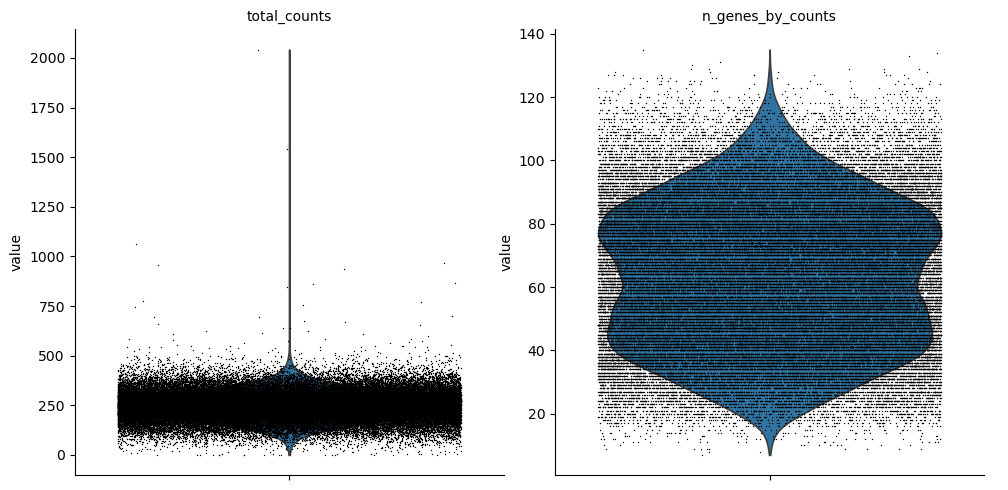

                    total_counts                        n_genes_by_counts  \
                          median        mean        std            median   
sample                                                                      
-28.999999999999996   244.563583  243.544998  64.268282              70.0   
-24.0                 247.810471  246.179337  64.629053              68.0   
-19.0                 256.897430  254.829575  68.545501              69.0   
-14.000000000000002   249.152054  245.640381  67.851487              70.0   
-9.0                  262.212677  258.678864  69.760098              70.0   
-4.0                  245.080978  243.741760  69.369264              68.0   
1.0                   291.321655  288.287384  78.454654              65.0   
6.0                   263.535614  260.393066  75.620155              60.0   
11.0                  241.044693  240.835938  75.031600              55.0   
16.0                  232.734695  234.255402  71.048503              54.0   

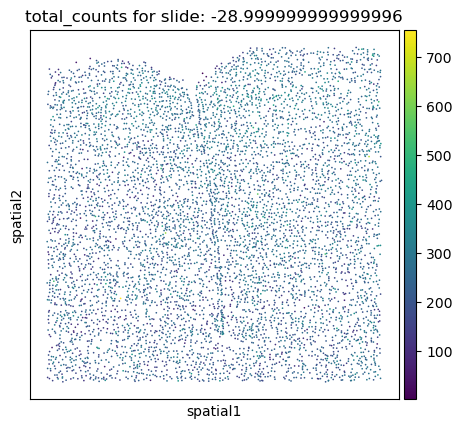

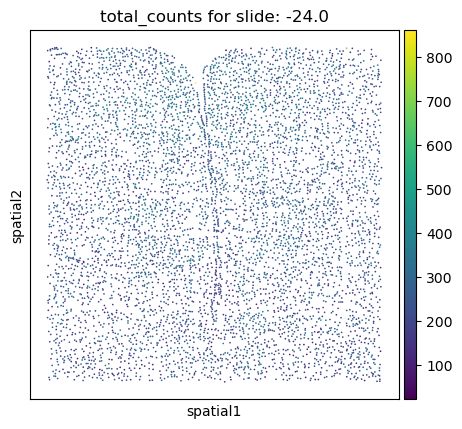

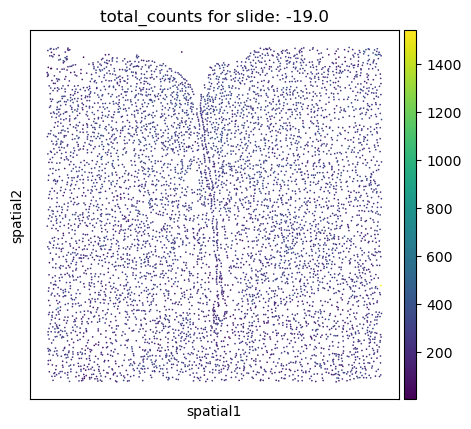

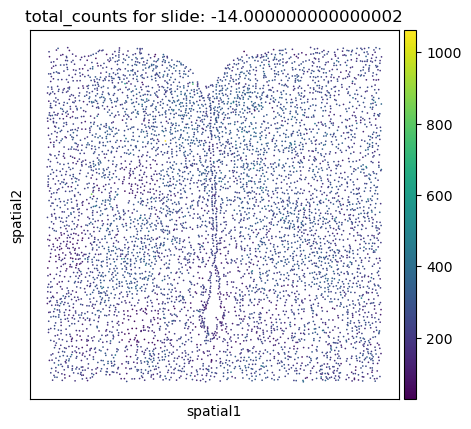

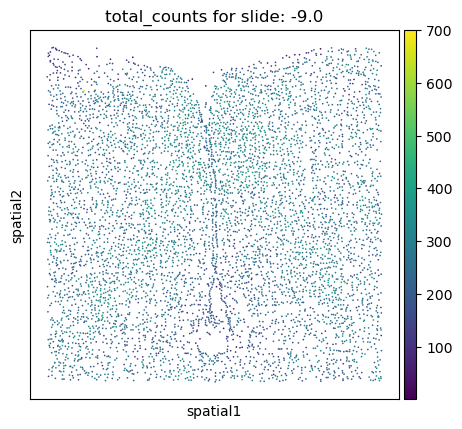

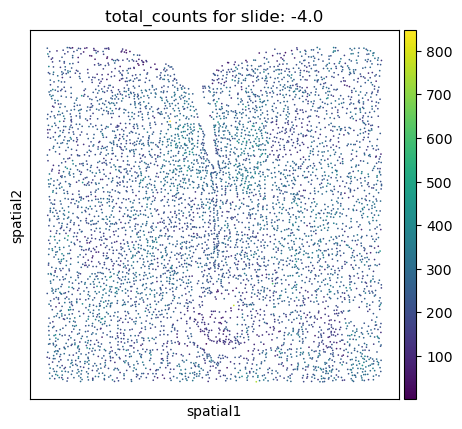

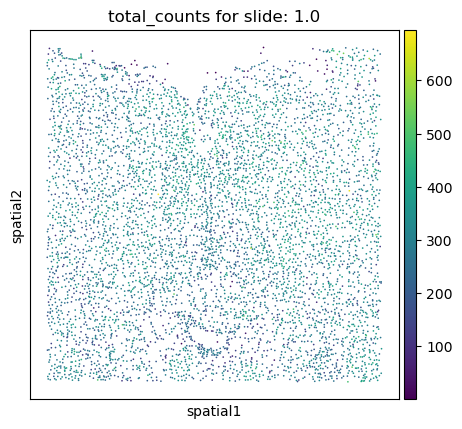

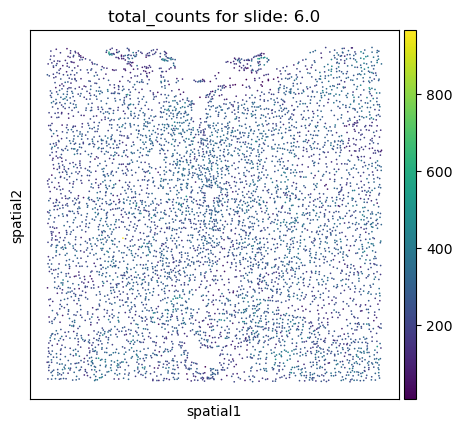

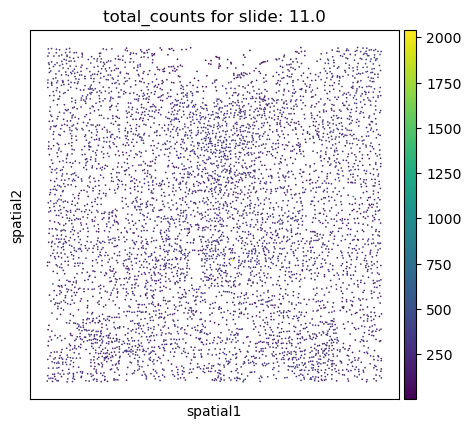

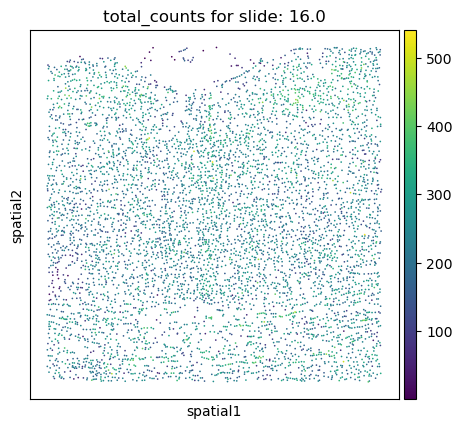

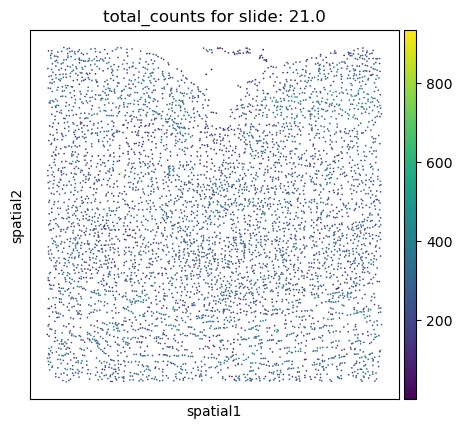

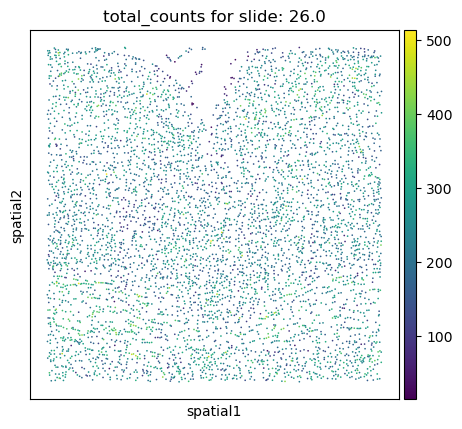

In [74]:
##reference code:
import scanpy as sc
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("Mt-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^Hb[^(P)]")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[50,])

# QC plots
sc.pl.violin(
    adata,
    ["total_counts", "n_genes_by_counts"],
    jitter=0.4,
    multi_panel=True,
    show=True
)

# Edge artifacts / per-slide gradients (simple diagnostics; no filtering by default)
if "sample" in adata.obs:
    # store quick per-sample QC summaries in .uns
    qc_by_sample = (
        adata.obs.groupby("sample")[["total_counts", "n_genes_by_counts"]]
        .agg(["median", "mean", "std"])
    )
    adata.uns["qc_by_sample"] = qc_by_sample

print(qc_by_sample)


# counts / QC overlay in space (helpful for spotting gradients)
if "sample" in adata.obs:
    for s in np.unique(adata.obs['sample']):
        adata_copy = adata[adata.obs['sample'] == s].copy()
        sc.pl.spatial(adata_copy, color="total_counts", spot_size = 0.005, title = "total_counts for slide: " + str(s), show=True)
else:
    sc.pl.spatial(adata_copy, color="total_counts", spot_size = 0.005, show=True)

In [10]:
def check_step2_qc_metrics(adata: "ad.AnnData") -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    # var flags
    ok, missing = _has_all(adata.var, ["mt", "ribo", "hb"])
    checks["var_flags_present"] = ok
    if not ok:
        errors.append(f"Missing var flags: {missing}")

    required_obs = [
        "n_genes_by_counts",
        "total_counts",
        "pct_counts_mt",
        "log1p_total_counts",
        "log1p_n_genes_by_counts",
    ]
    ok, missing = _has_all(adata.obs, required_obs)
    checks["qc_obs_keys_present"] = ok
    if not ok:
        errors.append(f"Missing qc obs keys: {missing}")

    # sanity
    if "pct_counts_mt" in adata.obs:
        pct = adata.obs["pct_counts_mt"].to_numpy()
        checks["pct_counts_mt_min"] = float(np.nanmin(pct))
        checks["pct_counts_mt_max"] = float(np.nanmax(pct))
        if np.nanmin(pct) < -1e-6 or np.nanmax(pct) > 100 + 1e-6:
            errors.append("pct_counts_mt out of expected range [0,100]")

    return StepResult("step2_qc_metrics", len(errors) == 0, checks, errors)

In [21]:
out2 = check_step2_qc_metrics(adata)
out2.passed

True

# Task 3: filter

In [ ]:
'''
Generate concise, executable Python code using Scanpy to perform basic single-cell RNA-seq filtering on an AnnData object named adata for both cells and genes.
'''

In [75]:
##reference code:
sc.pp.filter_cells(adata, max_counts=400)
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
sc.pp.filter_genes(adata, min_cells=10)

In [13]:
def check_step3_filter(adata: "ad.AnnData", prev: Optional["ad.AnnData"] = None) -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    checks["n_obs"] = int(adata.n_obs)
    checks["n_vars"] = int(adata.n_vars)

    if prev is not None:
        checks["prev_n_obs"] = int(prev.n_obs)
        checks["prev_n_vars"] = int(prev.n_vars)
        if adata.n_obs > prev.n_obs:
            errors.append("n_obs increased after filtering (unexpected)")
        if adata.n_vars > prev.n_vars:
            errors.append("n_vars increased after filtering (unexpected)")

    return StepResult("step3_filter", len(errors) == 0, checks, errors)

In [14]:
out3 = check_step3_filter(adata)
out3.passed

True

# Task 4: normalization

In [21]:
'''
You are an expert in single-cell RNA-seq analysis using Python and Scanpy.
Please write Python code that preprocesses an AnnData object adata by:
1.	Saving the raw count matrix into adata.layers["counts"] 
2.	Normalizing total counts per cell to the median library size.
3.	Applying transformation to the normalized data.
'''

In [76]:
##reference code:
# Saving count data
adata.layers["counts"] = adata.X.copy()
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [ ]:
def check_step4_normalize_log1p(adata: "ad.AnnData") -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    # raw preservation policy: accept either adata.raw OR layers['counts']
    raw_ok = adata.raw is not None
    layers_ok = "counts" in adata.layers

    checks["raw_present"] = bool(raw_ok)
    checks["layers_counts_present"] = bool(layers_ok)

    if not (raw_ok or layers_ok):
        errors.append("Raw counts not preserved: expected adata.raw or layers['counts']")

    # log1p sanity: values should be non-negative and finite (common)
    # Note: sparse matrices handled via .X.data
    X = adata.X
    try:
        if hasattr(X, "data"):
            data = X.data
        else:
            data = np.asarray(X).ravel()
        checks["X_finite"] = bool(np.isfinite(data).all())
        if not np.isfinite(data).all():
            errors.append(".X contains non-finite values")
        # after log1p of normalized counts, should typically be >= 0 (allow tiny negative numerical)
        mn = float(np.min(data)) if data.size else 0.0
        checks["X_min"] = mn
        if mn < -1e-6:
            errors.append(f".X min is negative ({mn}); unexpected after log1p")
    except Exception as e:
        errors.append(f"Could not inspect .X: {e}")

    return StepResult("step4_normalize_log1p", len(errors) == 0, checks, errors)

In [17]:
out4 = check_step4_normalize_log1p(adata)
out4.passed

True

# Task 5: hvg and pca

In [1]:
'''
Please write concise, executable Python code that takes an existing AnnData object adata and:
1.	Identifies highly variable genes using sc.pp.highly_variable_genes
2.	Runs PCA on the filtered features.
'''

'\nPlease write concise, executable Python code that takes an existing AnnData object adata and:\n1.\tIdentifies highly variable genes using sc.pp.highly_variable_genes\n2.\tRuns PCA on the filtered features.\n'

In [77]:
##reference code:
sc.pp.highly_variable_genes(adata, n_top_genes=161, batch_key="sample") # change n_top_genes for other datasets, this dataset only has 161 genes
sc.pp.pca(adata)
sc.tl.pca(adata)

In [ ]:
def check_step5_hvg_pca(adata: "ad.AnnData", hvg_range: Tuple[int, int] = (1900, 2100)) -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    if "highly_variable" not in adata.var:
        errors.append("Missing var['highly_variable']")
        checks["hvg_count"] = None
    else:
        hvg = adata.var["highly_variable"].to_numpy()
        hvg_count = int(np.sum(hvg.astype(bool)))
        checks["hvg_count"] = hvg_count
        lo, hi = hvg_range
        if not (lo <= hvg_count <= hi):
            errors.append(f"HVG count {hvg_count} outside expected range [{lo},{hi}]")

    if "X_pca" not in adata.obsm:
        errors.append("Missing obsm['X_pca']")
    else:
        Xp = np.asarray(adata.obsm["X_pca"])
        checks["X_pca_shape"] = list(Xp.shape)
        if Xp.ndim != 2 or Xp.shape[0] != adata.n_obs:
            errors.append("X_pca has wrong shape")
        if not _is_finite_array(Xp):
            errors.append("X_pca has non-finite values")

    return StepResult("step5_hvg_pca", len(errors) == 0, checks, errors)

In [31]:
out5 = check_step5_hvg_pca(adata, (160,162))
out5.passed

True

# Task 6: neighbor+umap

In [31]:
'''
Please write Python code that performs neighborhood graph construction and downstream visualization on an AnnData object adata by:
1.	Computing the k-nearest neighbor graph.
2.	Running Leiden clustering.
3.	Computing a UMAP embedding.
'''

/home/tl688/.conda/envs/agent4bench/lib/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 22713 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


In [ ]:
##reference code:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [ ]:
def check_step6_neighbors_umap(adata: "ad.AnnData") -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    if "connectivities" not in adata.obsp:
        errors.append("Missing obsp['connectivities']")
    else:
        checks["connectivities_shape"] = list(np.asarray(adata.obsp["connectivities"]).shape)

    if "X_umap" not in adata.obsm:
        errors.append("Missing obsm['X_umap']")
    else:
        Xu = np.asarray(adata.obsm["X_umap"])
        checks["X_umap_shape"] = list(Xu.shape)
        if Xu.shape != (adata.n_obs, 2):
            errors.append("X_umap has wrong shape; expected (n_obs, 2)")
        if not _is_finite_array(Xu):
            errors.append("X_umap has non-finite values")
        # ensure not all identical
        checks["X_umap_var_sum"] = float(np.var(Xu, axis=0).sum())
        if float(np.var(Xu, axis=0).sum()) <= 0.0:
            errors.append("X_umap appears constant")

    return StepResult("step6_neighbors_umap", len(errors) == 0, checks, errors)

In [42]:
out6 = check_step6_neighbors_umap(adata)
out6.passed

True

# Task 7: Spatial neighbor graph construction​

In [79]:
##reference code: 
sq.gr.spatial_neighbors(adata,
                        coord_type="generic",
                        spatial_key="spatial",
                        n_neighs=8)

# Make adjacency matrix symmetric
adata.obsp["spatial_connectivities"] = (
    adata.obsp["spatial_connectivities"].maximum(
        adata.obsp["spatial_connectivities"].T))

In [68]:
def check_step7_spatial_graph(adata: "ad.AnnData") -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    if "spatial_connectivities" not in adata.obsp:
        errors.append("Missing obsp['spatial_connectivities']")
    else:
        Xs = adata.obsp["spatial_connectivities"]
        checks["spatial_connectivities_shape"] = list(Xs.shape)
        # check shape
        if Xs.shape != (adata.n_obs, adata.n_obs):
            errors.append("spatial_connectivities has wrong shape; expected (n_obs, n_obs)")
        # check symmetric
        if not (Xs != Xs.T).nnz == 0:
            errors.append("spatial_connectivities not symmetric")
        # check all finite
        if not np.isfinite(Xs.data).all():
            errors.append("spatial_connectivities has non-finite values")
        # ensure not all zeros/identical
        checks["spatial_connectivities_nnz"] = int(Xs.nnz)
        if Xs.nnz == 0:
            errors.append("spatial_connectivities appears constant (all zeros)")


    return StepResult("step7_spatial_graph", len(errors) == 0, checks, errors)

In [69]:
out7 = check_step7_spatial_graph(adata)
out7.passed

True

# Task 8: bec

In [2]:
'''
Write a code to run the best batch effect correction method for one anndata object (adata) whose batch labels are stored in "sample" key.
'''

'\nWrite a code to run the best batch effect correction method for one anndata object (adata) whose batch labels are stored in "sample" key.\n'

In [80]:
##reference code:
sc.pp.combat(adata, 'sample')
sc.tl.pca(adata)

In [ ]:
import scib_metrics
import numpy as np
import scanpy as sc

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

%matplotlib inline
def evaluate_bec(adata, batch_label = 'sample', celltype_label = 'cell_type', n_jobs=1, use_rep='X_pca'):
    bm = Benchmarker(
        adata,
        batch_key=batch_label,
        label_key=celltype_label,
        bio_conservation_metrics=BioConservation(),
        batch_correction_metrics=BatchCorrection(),
        embedding_obsm_keys=[use_rep],
        n_jobs=n_jobs,
    )
    bm.benchmark()
    
    return bm

if 'X_pca_harmony' in list(adata.obsm.keys()):
    bm = evaluate_bec(adata, use_rep = 'X_pca_harmony')
    out8 = bm.get_results(min_max_scale=False)
elif 'X_pca' in list(adata.obsm.keys()):
    bm = evaluate_bec(adata, use_rep = 'X_pca')
    out8 = bm.get_results(min_max_scale=False)
else:
    import pandas as pd

    # Define columns
    columns = [
        "Isolated labels", "KMeans NMI", "KMeans ARI", "Silhouette label",
        "cLISI", "Silhouette batch", "iLISI", "KBET",
        "Graph connectivity", "PCR comparison",
        "Batch correction", "Bio conservation",
        "Total", "(X_pca, Total)"
    ]

    # Create the dataframe
    out8 = pd.DataFrame(
        [
            [
                0, 0, 0, 0,
                0, 0, 0, 0,
                0, 0.0,
                0, 0,
                0, 0
            ],
            [
                "Bio conservation", "Bio conservation", "Bio conservation", "Bio conservation",
                "Bio conservation", "Batch correction", "Batch correction", "Batch correction",
                "Batch correction", "Batch correction",
                "Aggregate score", "Aggregate score",
                "Aggregate score", 0
            ]
        ],
        index=["X_pca", "Metric Type"],
        columns=columns
    )

# Task 9: clustering evaluation

In [40]:
'''
Write a code to run the best clustering method for one anndata object (adata) and store the clustering label as 'cluster'
'''

/tmp/ipykernel_2050945/66170900.py:48: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


In [83]:
##reference code:
w_expr, w_spatial = 1.0, 0.3
C = (w_expr * adata.obsp["connectivities"]) + (w_spatial * adata.obsp["spatial_connectivities"])
C = C.maximum(C.T)  # keep symmetric

adata_copy = adata.copy()
adata_copy.obsp["connectivities"] = C
sc.tl.leiden(adata_copy)
adata_copy

AnnData object with n_obs × n_vars = 72241 × 160
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch', 'sample', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'clusters', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Cell_class_colors', 'qc_by_sample', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'spatial_neighbors'
    obsm: 'spatial', 'spatial3d', 'X_pca', 'X_u

In [88]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from typing import Dict, Any, Optional, Sequence, Tuple, List

import numpy as np
from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
    fowlkes_mallows_score,
    confusion_matrix,
)

# -------------------------
# Core evaluation
# -------------------------

@dataclass
class ClusteringEvalReport:
    n: int
    n_clusters: int
    n_celltypes: int
    metrics: Dict[str, float]
    mapping: Dict[str, str]  # cluster -> majority celltype
    purity_by_cluster: Dict[str, float]
    confusion: Dict[str, Any]  # lightweight confusion summary


def _to_str_array(x: Sequence) -> np.ndarray:
    arr = np.asarray(x)
    if arr.ndim != 1:
        raise ValueError(f"Expected 1D labels, got shape {arr.shape}")
    return arr.astype(str)


def _majority_mapping(
    cluster: np.ndarray,
    celltype: np.ndarray,
) -> Tuple[Dict[str, str], Dict[str, float]]:
    """
    Returns:
      - mapping: cluster_label -> majority celltype label
      - purity_by_cluster: fraction of majority celltype within each cluster
    """
    mapping: Dict[str, str] = {}
    purity: Dict[str, float] = {}

    for c in np.unique(cluster):
        mask = cluster == c
        ct = celltype[mask]
        # handle empty cluster (shouldn't happen but safe)
        if ct.size == 0:
            mapping[c] = "NA"
            purity[c] = 0.0
            continue

        vals, counts = np.unique(ct, return_counts=True)
        best_idx = int(np.argmax(counts))
        mapping[c] = str(vals[best_idx])
        purity[c] = float(counts[best_idx] / ct.size)

    return mapping, purity


def evaluate_clustering_vs_celltypes(
    cluster_labels: Sequence,
    annotated_celltypes: Sequence,
    *,
    ignore_labels: Optional[Sequence[str]] = None,
    spatial_connectivities=None,
) -> ClusteringEvalReport:
    """
    Evaluate clustering labels against annotated cell types.

    Inputs
    ------
    cluster_labels: array-like of shape (n_cells,)
      Predicted cluster assignments (strings/ints ok).
    annotated_celltypes: array-like of shape (n_cells,)
      Ground-truth or reference cell type labels.

    ignore_labels: optional list of celltype labels to exclude
      e.g. ['Unknown', 'Doublet', 'Unassigned']

    Outputs
    -------
    A report with:
      - ARI, AMI, NMI, V-measure (H/C/V), FMI
      - Purity (overall) and per-cluster purity
      - Majority-vote mapping cluster -> celltype
      - Confusion matrix summary (counts + label order)
    """
    cl = _to_str_array(cluster_labels)
    ct = _to_str_array(annotated_celltypes)

    if cl.shape[0] != ct.shape[0]:
        raise ValueError(f"Length mismatch: cluster={cl.shape[0]} vs celltype={ct.shape[0]}")

    # filter NaNs / missing / ignored cell types
    mask = np.ones_like(ct, dtype=bool)
    mask &= (ct != "nan") & (ct != "None") & (ct != "NA") & (ct != "")
    if ignore_labels is not None:
        ignore_set = set(map(str, ignore_labels))
        mask &= ~np.isin(ct, list(ignore_set))

    cl_f = cl[mask]
    ct_f = ct[mask]

    if cl_f.size == 0:
        raise ValueError("No cells left after filtering. Check ignore_labels / missing labels.")

    # Standard information-theoretic / partition similarity metrics
    ari = float(adjusted_rand_score(ct_f, cl_f))
    ami = float(adjusted_mutual_info_score(ct_f, cl_f))
    nmi = float(normalized_mutual_info_score(ct_f, cl_f))
    h, c, v = homogeneity_completeness_v_measure(ct_f, cl_f)
    fmi = float(fowlkes_mallows_score(ct_f, cl_f))

    # Majority mapping + purity
    mapping, purity_by_cluster = _majority_mapping(cl_f, ct_f)
    # overall purity = sum over clusters (size(cluster) * purity(cluster)) / n
    overall_purity = 0.0
    for c_lbl in np.unique(cl_f):
        m = cl_f == c_lbl
        overall_purity += m.sum() * purity_by_cluster[str(c_lbl)]
    overall_purity = float(overall_purity / cl_f.size)

    # Confusion matrix (celltype x cluster)
    celltype_order = sorted(np.unique(ct_f).tolist())
    cluster_order = sorted(np.unique(cl_f).tolist())
    cm = confusion_matrix(ct_f, cl_f, labels=celltype_order)  # rows=celltypes, cols=clusters

    if spatial_connectivities is not None:
        A = spatial_connectivities[mask][:, mask]  # keep nodes that remained after filtering
        labels = pd.Categorical(cl_f)
        codes = labels.codes.astype(float)  # numeric labels for Moran's I

        # Row-standardize weights
        rs = np.asarray(A.sum(axis=1)).ravel().astype(float)
        rs[rs == 0] = 1.0
        W = A.multiply(1.0 / rs[:, None])

        z = codes - codes.mean()
        den = float(np.dot(z, z))
        if den == 0.0:
            I = 0.0
        else:
            num = float(z @ (W @ z))
            I = num / den

    metrics = {
        "ARI": ari,
        "AMI": ami,
        "NMI": nmi,
        "Homogeneity": float(h),
        "Completeness": float(c),
        "V-measure": float(v),
        "FMI": fmi,
        "Purity": overall_purity,
        "Gloabl_Moran_I": float(I)
    }

    confusion = {
        "celltype_order": celltype_order,
        "cluster_order": cluster_order,
        "matrix": cm.tolist(),  # keep JSON-friendly
    }

    return ClusteringEvalReport(
        n=int(cl_f.size),
        n_clusters=int(len(cluster_order)),
        n_celltypes=int(len(celltype_order)),
        metrics=metrics,
        mapping=mapping,
        purity_by_cluster=purity_by_cluster,
        confusion=confusion,
    )


In [99]:
key = 'leiden'
try:
    out9 = evaluate_clustering_vs_celltypes(adata_copy.obs[key], adata_copy.obs['cell_type'], spatial_connectivities = adata_copy.obsp['spatial_connectivities'])
except:
    metrics = {
        "ARI": 0,
        "AMI": 0,
        "NMI": 0,
        "Homogeneity": 0,
        "Completeness": 0,
        "V-measure": 0,
        "FMI": 0,
        "Purity": 0,
        "Gloabl_Moran_I": 0,
    }
    out9 = ClusteringEvalReport(
        n=1,
        n_clusters=1,
        n_celltypes=1,
        metrics=metrics,
        mapping={},
        purity_by_cluster={},
        confusion={},
    )

In [100]:
out9.metrics

{'ARI': 0.272785958474545,
 'AMI': 0.533342572797424,
 'NMI': 0.5337766320973357,
 'Homogeneity': 0.6458147275950639,
 'Completeness': 0.4548651133181088,
 'V-measure': 0.5337766320973357,
 'FMI': 0.3887008412062242,
 'Purity': 0.7620880109633034,
 'Gloabl_Moran_I': 0.13074587032536109}

# Task 10: SVG + DEG

In [3]:
 # here we need refernece profile...
'''
Write a code to run the best differential expression gene detection method for one anndata object (adata).
'''

'\nWrite a code to run the best differential expression gene detection method for one anndata object (adata).\n'

In [106]:
##reference code:

# global
sq.gr.spatial_autocorr(adata, mode="moran")
svg_global = adata.uns["moranI"].sort_values("I", ascending=False)
print(svg_global.head())

# per cell_class
cell_key = "cell_type"
svgs_by_class = {}

for cls in adata.obs["cell_type"].cat.categories:
    idx = adata.obs["cell_type"] == cls
    if idx.sum() < 200:   # adjust threshold
        continue
    ad = adata[idx].copy()
    sq.gr.spatial_autocorr(ad, mode="moran")
    svgs_by_class[str(cls)] = ad.uns["moranI"].sort_values("I", ascending=False)
print(svgs_by_class['Microglia'].head())

# DEG
sc.tl.rank_genes_groups(adata, groupby='cell_type')

             I  pval_norm  var_norm  pval_norm_fdr_bh
Nnat  0.321812        0.0  0.000003               0.0
Mbp   0.244101        0.0  0.000003               0.0
Irs4  0.211777        0.0  0.000003               0.0
Sln   0.199568        0.0  0.000003               0.0
Gad1  0.178052        0.0  0.000003               0.0
                I     pval_norm  var_norm  pval_norm_fdr_bh
Mbp      0.696585  0.000000e+00  0.006017      0.000000e+00
Ermn     0.541227  1.413314e-12  0.006017      1.130651e-10
Adcyap1  0.319639  1.818143e-05  0.006017      9.696761e-04
Opalin   0.298961  5.602933e-05  0.006017      2.241173e-03
Crh      0.280609  1.437649e-04  0.006017      4.600476e-03


/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py

In [ ]:
# We have the ground truth SVG sets from: https://academic.oup.com/bioinformatics/article/41/4/btaf131/8096371
# Each ground truth SVG set contains genes likely to be SVGs based on various evidence and perspectives

In [ ]:
import math
from typing import Dict, Iterable, List, Set, Tuple, Optional

# ---------- basic utilities ----------

def _norm_gene(g: str) -> str:
    """Normalize gene symbols: strip + uppercase. Adjust if you prefer case-sensitive."""
    return g.strip().upper()

def normalize_gene_set(genes: Iterable[str]) -> Set[str]:
    return {_norm_gene(g) for g in genes if g is not None and str(g).strip() != ""}

def _log_choose(n: int, k: int) -> float:
    if k < 0 or k > n:
        return float("-inf")
    # log(C(n,k)) via lgamma for stability
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)

def hypergeom_sf(k_minus_1: int, M: int, K: int, n: int) -> float:
    """
    Survival function P[X >= k] for Hypergeometric(M, K, n).
      M: population size
      K: number of successes in population
      n: draws
      X: overlap (successes in draws)
    """
    # sum_{x=k..min(K,n)} [C(K,x) C(M-K, n-x) / C(M,n)]
    k = k_minus_1 + 1
    max_x = min(K, n)
    if k > max_x:
        return 0.0
    denom = _log_choose(M, n)
    total = 0.0
    for x in range(k, max_x + 1):
        logp = _log_choose(K, x) + _log_choose(M - K, n - x) - denom
        total += math.exp(logp)
    return min(1.0, max(0.0, total))

def benjamini_hochberg(pvals: List[float]) -> List[float]:
    """BH-FDR; returns q-values in original order."""
    m = len(pvals)
    order = sorted(range(m), key=lambda i: pvals[i])
    q = [0.0] * m
    prev = 1.0
    for rank, i in enumerate(reversed(order), start=1):
        idx = i
        # ranks from largest to smallest p
        r = m - rank + 1
        val = pvals[idx] * m / r
        prev = min(prev, val)
        q[idx] = min(1.0, prev)
    return q

# ---------- pairwise overlap metrics ----------

def overlap_metrics(
    A: Set[str],
    B: Set[str],
) -> Dict[str, float]:
    """Return overlap metrics for two sets A and B."""
    inter = A & B
    a, b, i = len(A), len(B), len(inter)
    u = a + b - i
    jaccard = (i / u) if u else 1.0
    overlap_coef = (i / min(a, b)) if min(a, b) else 1.0
    precision = (i / a) if a else 0.0   # "of A, how many in B"
    recall = (i / b) if b else 0.0      # "of B, how many in A"
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return {
        "n_A": float(a),
        "n_B": float(b),
        "n_intersection": float(i),
        "jaccard": jaccard,
        "overlap_coef": overlap_coef,
        "precision(A_in_B)": precision,
        "recall(B_covered_by_A)": recall,
        "f1": f1,
    }

def overlap_enrichment_pval(
    A: Set[str],
    B: Set[str],
    universe: Set[str],
) -> float:
    """
    Hypergeometric enrichment p-value for overlap between A and B given a universe.
    Treat A as 'success set' (K=|A|), B as draws (n=|B|), overlap x=|A∩B|.
    """
    A_u = A & universe
    B_u = B & universe
    M = len(universe)
    K = len(A_u)
    n = len(B_u)
    x = len(A_u & B_u)
    if M == 0:
        return 1.0
    # P[X >= x]
    return hypergeom_sf(x - 1, M, K, n)

# ---------- main: evaluate overlap across cell types ----------

def evaluate_marker_overlap(
    markers_1: Dict[str, Iterable[str]],
    markers_2: Dict[str, Iterable[str]],
    universe: Optional[Iterable[str]] = None,
    match_mode: str = "same_celltype",  # "same_celltype" or "all_pairs"
) -> List[Dict[str, object]]:
    """
    markers_1 / markers_2: dict celltype -> genes
    universe: optional gene universe (e.g., all genes tested / expressed); strongly recommended for p-values.
    match_mode:
      - "same_celltype": compare same-named cell types present in both dicts
      - "all_pairs": compare every celltype in markers_1 vs every celltype in markers_2
    Returns list of result dicts (easy to turn into a DataFrame).
    """
    m1 = {ct: normalize_gene_set(gs) for ct, gs in markers_1.items()}
    m2 = {ct: normalize_gene_set(gs) for ct, gs in markers_2.items()}

    if universe is None:
        # fall back to union of all genes observed across both marker collections
        uni = set().union(*m1.values(), *m2.values()) if (m1 or m2) else set()
    else:
        uni = normalize_gene_set(universe)

    pairs: List[Tuple[str, str]] = []
    if match_mode == "same_celltype":
        shared = sorted(set(m1.keys()) & set(m2.keys()))
        pairs = [(ct, ct) for ct in shared]
    elif match_mode == "all_pairs":
        pairs = [(ct1, ct2) for ct1 in sorted(m1.keys()) for ct2 in sorted(m2.keys())]
    else:
        raise ValueError("match_mode must be 'same_celltype' or 'all_pairs'")

    out: List[Dict[str, object]] = []
    pvals: List[float] = []

    for ct1, ct2 in pairs:
        A = m1[ct1]
        B = m2[ct2]
        metrics = overlap_metrics(A, B)
        p = overlap_enrichment_pval(A, B, uni)
        pvals.append(p)
        out.append({
            "celltype_1": ct1,
            "celltype_2": ct2,
            **metrics,
            "p_hypergeom": p,
        })

    # FDR across all tested pairs
    qvals = benjamini_hochberg(pvals) if pvals else []
    for row, q in zip(out, qvals):
        row["q_bh_fdr"] = q

    return out

In [49]:
import pandas as pd
pancreas_ground = pd.read_pickle("/gpfs/gibbs/pi/zhao/wl545/results/pancreas_markers_db.pkl")

In [51]:
# adata.uns['rank_genes_groups']['names'].keys()
def get_top_markers_dict(adata, n_top=10):
    """
    Extract top marker genes for each group from adata.uns['rank_genes_groups'].

    Returns
    -------
    dict
        {cell_type: [gene1, gene2, ..., geneN]}
    """
    try:
        rg = adata.uns["rank_genes_groups"]
        groups = rg["names"].dtype.names

        marker_dict = {
            g: list(rg["names"][g][:n_top])
            for g in groups
        }
    except:
        marker_dict = {}
    return marker_dict

In [ ]:
# 
markers_a = get_top_markers_dict(adata)
markers_b = pancreas_ground
out10 = evaluate_marker_overlap(
    markers_1=markers_a,
    markers_2=markers_b,
    universe=None,              # ideally: pass the genes tested/expressed in your scRNA-seq
    match_mode="same_celltype", # or "all_pairs" to build a cross-type overlap matrix
)

In [53]:
def average_overlap_scores(results):
    """
    Compute average overlap metrics from a list of overlap result dicts.

    Averages:
    - jaccard
    - overlap_coef
    - precision(A_in_B)
    - recall(B_covered_by_A)
    - f1
    """
    keys = [
        "jaccard",
        "overlap_coef",
        "precision(A_in_B)",
        "recall(B_covered_by_A)",
        "f1",
    ]

    avg_scores = {}
    for k in keys:
        values = [r[k] for r in results if k in r]
        avg_scores[k] = sum(values) / len(values) if values else float("nan")

    return avg_scores
out10 = average_overlap_scores(out10)

# Task 11: neighborhood enrichment + co-occurence

  0%|          | 0/1000 [00:00<?, ?/s]

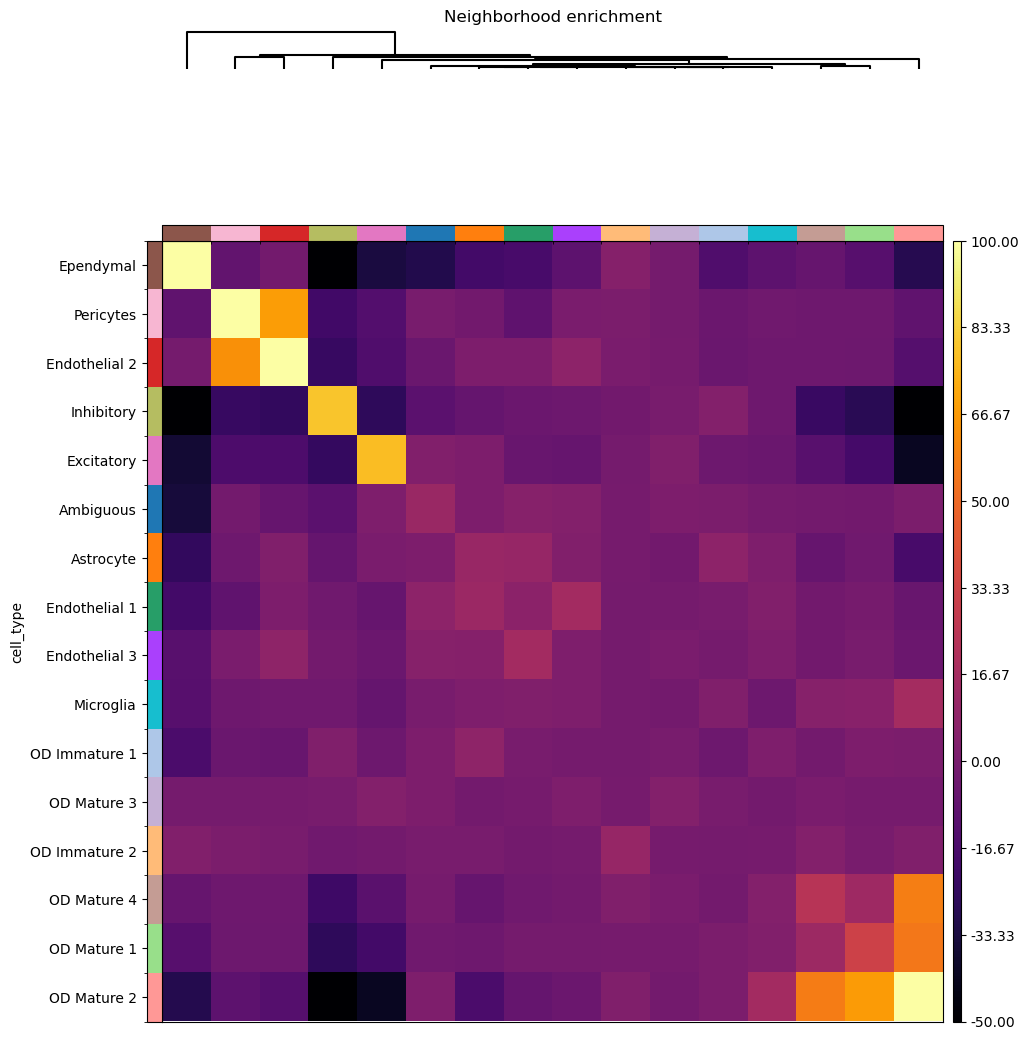

In [107]:
##reference code:
sq.gr.spatial_neighbors(adata, coord_type="generic", spatial_key="spatial3d") # if using 3d, need to rerun spatial neighbor graph
sq.gr.nhood_enrichment(adata, cluster_key="cell_type")
sq.pl.nhood_enrichment(
    adata, cluster_key="cell_type", method="single", cmap="inferno", vmin=-50, vmax=100
)

  0%|          | 0/666 [00:00<?, ?/s]

ERROR: Unable to fetch palette, reason: 'cell_type_colors'. Using `None`.


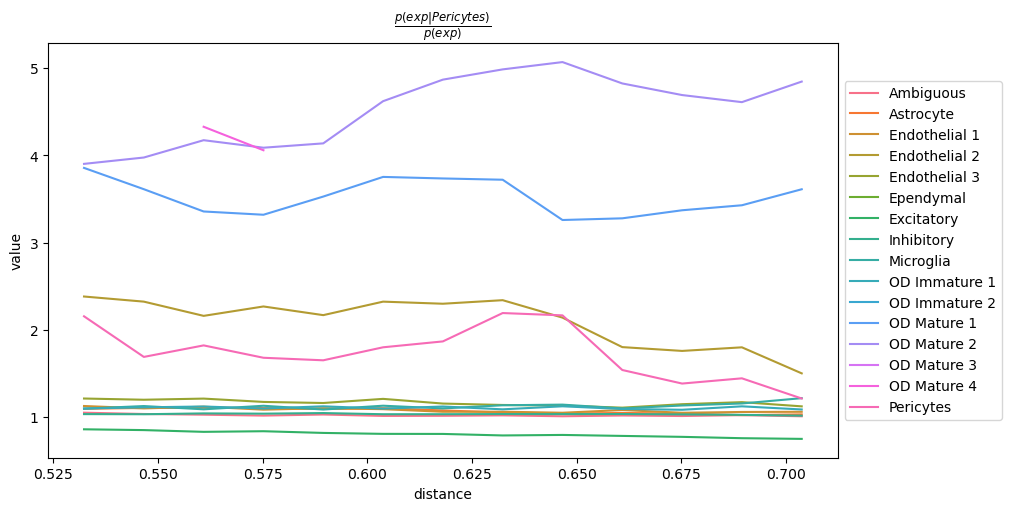

In [110]:
sq.gr.co_occurrence(adata, cluster_key="cell_type")
sq.pl.co_occurrence(
    adata,
    cluster_key="cell_type",
    clusters="Pericytes",
    figsize=(10, 5),
)

# Task 12: lr-interaction

In [112]:
sq.gr.ligrec(
    adata,
    n_perms=100,
    cluster_key="cell_type",
    use_raw = False
)
sq.pl.ligrec(
    adata,
    cluster_key="cell_type",
    source_groups="Inhibitory",
    target_groups=["Microglia"],
    swap_axes=True,
)

0.00B [00:00, ?B/s]

  File "/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/urllib3/response.py", line 712, in _error_catcher
    yield
  File "/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/urllib3/response.py", line 1074, in read_chunked
    chunk = self._handle_chunk(amt)
  File "/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/urllib3/response.py", line 1025, in _handle_chunk
    returned_chunk = self._fp._safe_read(self.chunk_left)  # type: ignore[union-attr]
  File "/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/http/client.py", line 613, in _safe_read
    data = self.fp.read(amt)
  File "/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/socket.py", line 669, in readinto
    return self._sock.recv_into(b)
  File "/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/ssl.py", line 1241, in recv_into
    return self.read(nbytes, buffer)
  File "/gpfs/gibbs/project/zhao/xc3

0.00B [00:00, ?B/s]

  File "/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/urllib3/response.py", line 712, in _error_catcher
    yield
  File "/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/urllib3/response.py", line 1074, in read_chunked
    chunk = self._handle_chunk(amt)
  File "/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/urllib3/response.py", line 1016, in _handle_chunk
    value = self._fp._safe_read(amt)  # type: ignore[union-attr]
  File "/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/http/client.py", line 613, in _safe_read
    data = self.fp.read(amt)
  File "/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/socket.py", line 669, in readinto
    return self._sock.recv_into(b)
ConnectionResetError: [Errno 104] Connection reset by peer

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/gpfs/gibbs/project/zhao/x

RuntimeError: No active exception to reraise

# Task 13: Trajectory Inference

In [ ]:
# Goal: identify pseudotime labels for each spot
# Problem: No ground truth label, existing benchmarking papers use either simulated datasets or compute spatial domain clustering related metrics (ARI and AMI), claiming that the higher this metric, the better the trajectory inference accuracy
# https://academic.oup.com/nar/article/53/15/gkaf791/8237896#530186962

# General evaluation

In [54]:
# test time:
import time
def time_func(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()
    return result, end - start


In [55]:
# test consistency:
#run code 10 times and compute the mean/variance/average pass rate.

In [56]:
out_list = [out1,out2,out3,out4,out5,out6,out7,out8,out9,out10]

In [61]:
def compute_leaderboard(out_list, method = 'reference'):
    score_list = []
    score_name = []
    for idx,item in enumerate(out_list[0:7]):
        taskid = idx+1
        score_name.append(f'task_{taskid}')
        print(item)
        score_list.append(item.passed*1.0)
        
    #bec
    bec_score = out_list[7]
    
    bec_score_full = bec_score ['Total'].values[0]
    score_name.append('task8_S_total')
    score_list.append(bec_score_full)
    #cluster
    clus_score = out_list[8].metrics
    for i in clus_score.keys():
        score_name.append(f'task9_{i}')
        score_list.append(clus_score[i])
    #deg
    deg_score = out_list[9]
    for i in deg_score.keys():
        score_name.append(f'task10_{i}')
        score_list.append(deg_score[i])
    score_list.append(np.mean(score_list))
    score_name.append('Average')
    df1 = pd.DataFrame(score_list)
    df1.index = score_name
    df1.columns = [method]
    
    return df1

In [62]:
df_out = compute_leaderboard(out_list, method = 'reference')

StepResult(step_id='step1_load_merge', passed=True, checks={'sample_nunique': 5, 'n_obs': 11125, 'n_vars': 26656}, errors=[])
StepResult(step_id='step2_qc_metrics', passed=True, checks={'var_flags_present': True, 'qc_obs_keys_present': True, 'pct_counts_mt_min': 0.0, 'pct_counts_mt_max': 72.70015658704901}, errors=[])
StepResult(step_id='step3_filter', passed=True, checks={'n_obs': 8455, 'n_vars': 22713}, errors=[])
StepResult(step_id='step4_scrublet', passed=False, checks={'scrublet_keys_present': False}, errors=["Missing scrublet keys: ['predicted_doublet', 'doublet_score']"])
StepResult(step_id='step5_normalize_log1p', passed=True, checks={'raw_present': False, 'layers_counts_present': True, 'X_finite': True, 'X_min': 0.00236134736264963}, errors=[])
StepResult(step_id='step6_hvg_pca', passed=False, checks={'hvg_count': None}, errors=["Missing var['highly_variable']", "Missing obsm['X_pca']"])
StepResult(step_id='step7_neighbors_umap', passed=True, checks={'connectivities_shape': []

In [63]:
df_out

,reference
task_1,1.000000
task_2,1.000000
task_3,1.000000
task_4,0.000000
task_5,1.000000
task_6,0.000000
task_7,1.000000
task8_S_total,0.513200
task9_ARI,0.250721
task9_AMI,0.643784


In [64]:
df_out.to_csv('reference_data.csv')